# Instrument definition

In [ ]:
%matplotlib widget
from pathlib import Path

import mcstasscript as ms

trex = ms.McStas_instr(
    "TRex",
    author="Bing Li",
    origin="DMSC",
    input_path="./mcstas",
    output_path="./mcstas/out",
)

mode = "HR"
off_file_path = Path("./../../OFF_files_swap") # from run_path

L0 = trex.add_parameter(
    "double",
    "L0",
    value=2.4,
    comment="wavelength in [Å] used to calculate the minimum and maximum wavelength "
    + "for the source component by adding and subtracting a set wavelength",
)

d_Li = trex.add_parameter(
    "double",
    "d_Li",
    value=0.845,
    comment="wavelength band in [Å] to be simulated",
)

trex.add_parameter(
    "int",
    "RRM",
    value=18,
    comment="repetition rate multiplication",
)

trex.add_parameter(
    "string",
    "mode",
    value=f'"{mode}"',
    comment="HR for High Resolution, HF for High Flux",
)


trex.add_parameter(
    "int",
    "mod_type",
    value=2,
    comment="this variable determines which moderator type is used "
    + r"{0: Thermal moderator, 1: Bispectral moderator, 2: Cold moderator}",
)

bender = trex.add_parameter(
    "int", "bender", value=1, comment="bender out = 0, bender in = 1"
)
b_rot = trex.add_parameter(
    "double",
    "b_rot",
    value=-0.5,
    comment="in [deg], rotation of the cold neutron bender",
)

coll = trex.add_parameter(
    "int",
    "coll",
    value=0,
    comment="Type of collimator"
    + r"{0: Guide anyshape, 1: Guide_honeycomb_1, 2: Guide_honeycomb_2}",
)

In [2]:
trex.set_parameters(L0=1.0, RRM=8, mod_type=0, mode='"HF"', bender=0)

In [3]:
trex.show_parameters()

double L0        = 1.0    // wavelength in [Å] used to calculate the minimum 
                              and maximum wavelength for the source component by 
                              adding and subtracting a set wavelength 
double d_Li      = 0.845  // wavelength band in [Å] to be simulated
int    RRM       = 8      // repetition rate multiplication
string mode      = "HF"   // HR for High Resolution, HF for High Flux
int    mod_type  = 0      // this variable determines which moderator type is 
                              used {0: Thermal moderator, 1: Bispectral moderator, 
                              2: Cold moderator} 
int    bender    = 0      // bender out = 0, bender in = 1
double b_rot     = -0.5   // in [deg], rotation of the cold neutron bender
int    coll      = 0      // Type of collimator{0: Guide anyshape, 1: 
                              Guide_honeycomb_1, 2: Guide_honeycomb_2} 


# Declare section

In [4]:
frac = trex.add_declare_var(
    "double",
    "frac",
    comment="Used in the Source component. Defines the statistical fraction of events"
    + "emitted from the cold part of the moderator, the value is determined later in the file"
    + " depending on the moderator type that was chosen",
)
lamb_1 = trex.add_declare_var("double", "lamb_1", comment="Wavelength min in [AA]")
lamb_2 = trex.add_declare_var("double", "lamb_2", comment="Wavelength max in [AA]")

In [5]:
trex.add_declare_var(
    "double",
    "T_offset",
    value=1.7e-3,
    comment="Time offset in [s] to shift to the center of long pulse",
)
trex.add_declare_var(
    "double",
    "f",
    value=14.0,
    # value=0.00001,
    comment="Source frequency in [Hz]",
)
trex.add_declare_var(
    "double",
    "v0",
    comment="characteristic velocity in [m/s]",
)

Declare variable: 'v0' of type double

In [6]:
trex.append_declare("""
// BW1 Chopper

double position_BW1[3] = {0.011348994153930106, 0.0, 32.0};
double rotation_BW1[3] = {0, 0.124542024141650, 0};
double radius_BW1 = 0.35; // [m]
double delta_y_BW1 = -0.3075; // [m]
double nslits_BW1 = 1;
char theta_pos_BW1[256] = "0";
char theta_width_BW1[256] = "61.4";

double tof_BW1; // [s]
double f_BW1; // frequency [Hz]
double delay_BW1; //time delay [s]

""")

In [7]:
trex.append_declare("""
// BW2 Chopper

double position_BW2[3] = {0.03140505829452013, 0.0, 40.0};
double rotation_BW2[3] = {0, 0.162739331227240, 0};
double radius_BW2 = 0.35; // [m]
double delta_y_BW2 = -0.3075; // [m]
double nslits_BW2 = 1;
char theta_pos_BW2[256] = "0";
char theta_width_BW2[256] = "63.3";


double tof_BW2; // [s]
double f_BW2; // frequency [Hz]
double delay_BW2; // time delay [s]


""")

In [8]:
trex.append_declare("""
// P1 Chopper

double position_P1[3] = {0.4108460115539497, 0.0, 107.95};
double rotation_P1[3] = {0, 0.430122381481144, 0};
double radius_P1 = 0.35; // [m]
double delta_y_P1 = 0.305; // [m]
double nslits_P1 = 4;
char theta_pos_P1[256] = "0;125;180;305"; // positive for CW
char theta_width_P1[256] = "20;35;20;35";


double tof_P1; // [s]
double f_P1; // frequency [Hz]
double delay_P1; //time delay [s]
double phase_P1; // angular delay [deg]
 """)

In [9]:
trex.append_declare("""
// P2 Chopper

double position_P2[3] = {0.41159673083080733, 0.0, 108.055};
double rotation_P2[3] = {0, 0.430122381481144, 0};
double radius_P2 = 0.35; // [m]
double delta_y_P2 = 0.305; // [m]
double nslits_P2 = 4;
char theta_pos_P2[256] = "0;125;180;305"; // positive for CW
char theta_width_P2[256] = "20;35;20;35";

double tof_P2; // [s]
double f_P2; // frequency [Hz]
double delay_P2; //time delay [s]
double phase_P2; // angular delay [deg]
 """)

In [10]:
trex.append_declare("""
// M1 Chopper

double position_M1[3] = {0.8166097806955753, 0.0, 161.995};
double rotation_M1[3] = {0, 0.430122381481144, 0};
double radius_M1 = 0.35; // [m]
double delta_y_M1 = 0.325; // [m]
double nslits_M1 = 2;
char theta_pos_M1[256] = "0;-175"; // positive for CW
char theta_width_M1[256] = "2.5;4.4";

double tof_M1; // [s]
double f_M1; // frequency [Hz]
double delay_M1; //time delay [s]
double phase_M1; // angular delay [deg]
""")

In [11]:
trex.append_declare("""
// M2 Chopper

double position_M2[3] = {0.8166097806955753, 0.0, 162.005};
double rotation_M2[3] = {0, 0.430122381481144, 0};
double radius_M2 = 0.35; // [m]
double delta_y_M2 = -0.325; // [m]
double nslits_M2 = 2;
char theta_pos_M2[256] = "0;-175"; // positive for CW
char theta_width_M2[256] = "2.5;4.4";

double tof_M2; // [s]
double f_M2; // frequency [Hz]
double delay_M2; //time delay [s]
double phase_M2; // angular delay [deg]
 """)

# Initialize section

In [12]:
trex.append_initialize("""
// Source type
switch (mod_type)
	{
	case 0: {frac = 0.0; break;} // Thermal moderator
	case 1: {frac = 0.5; break;} // Bispectral moderator
	case 2: {frac = 1.0; break;} // Cold moderator
	}
// Source parameters
lamb_1 = L0-d_Li*1.1;
lamb_2 = L0+d_Li*1.1;
""")
trex.append_initialize('printf("lamb_1: %g \\n", lamb_1);')
trex.append_initialize('printf("lamb_2: %g \\n", lamb_2);')
# // Source parameters
# 	vi = 2*PI*K2V/Li;
# 	v1 = 2*PI*K2V/lamb_1;   // slowest neutron
# 	v2 = 2*PI*K2V/lamb_2;   // fastest neutron

In [13]:
trex.append_initialize("""
// calculate frequencies
f_BW1 = f;
f_BW2 = f_BW1;
f_P1 = RRM*f*0.75;
f_P2 = -f_P1;
f_M1 = RRM*f;
f_M2 = -f_M1;
""")

In [14]:
trex.append_initialize("""
// calculate time delay
v0 = 2*PI*K2V/L0; // speed center neutron

// time of flight and chopper phases
tof_BW1 = T_offset + position_BW1[2]/v0;
tof_BW2 = T_offset + position_BW2[2]/v0;
tof_P1 = T_offset + position_P1[2]/v0;
tof_P2 = T_offset + position_P2[2]/v0;
tof_M1 = T_offset + position_M1[2]/v0;
tof_M2 = T_offset + position_M2[2]/v0;

//time delay
delay_BW1 = tof_BW1; 
delay_BW2 = tof_BW2; 
delay_P1 = tof_P1; 
delay_P2 = tof_P2;
delay_M1 = tof_M1;
delay_M2 = tof_M2;
""")

In [15]:
trex.append_initialize("""
// Calculate phase delay
if (strcmp(mode, "HR") == 0){
    phase_P1 = 0;
    phase_P2 = 0;
    phase_M1 = 0;
    phase_M2 = 0;
} else if (strcmp(mode, "HF") == 0){
    phase_P1 = -55;
    phase_P2 = -55;
    phase_M1 = -175;
    phase_M2 = -175;
} else {
    printf("Need valid resolution option, 'HR' or 'HF'");
}
""")

In [16]:
trex.show_variables()

DECLARE VARIABLES 
type    variable name  array length  value   
-------------------------------------------
double  frac                                 
double  lamb_1                               
double  lamb_2                               
double  T_offset                     0.0017  
double  f                            14.0    
double  v0                                   



# Trace section

In [17]:
# https://mcstas.org/download/components/3.7.9/sources/ESS_butterfly.html
source = trex.add_component(name="source", component_name="ESS_butterfly")
source.set_parameters(
    sector='"W"',
    beamline=7,
    yheight=0.03,  # [m], moderator height, 0.03 to 0.06
    cold_frac=frac,
    # target_index not needed if using dist
    dist=2,  # [m], distance to focusing rectange
    focus_xw=0.095,  # [m], size of focusing rectange
    focus_yh=0.035,
    # c_performance: float = 1.0
    # t_performance: float = 1.0
    Lmin=lamb_1,  # in Angstrom
    Lmax=lamb_2,  # in Angstrom
    n_pulses=1,
    acc_power=2,
    tfocus_dist="position_BW2[2]",  # [m], Position of time focusing window along z axis
    tfocus_time="tof_BW2",  # [s], position of time focusing window
    tfocus_width=0.02,  # [s], width of time focusing window
)

In [18]:
for i in range(9):
    if i in (2, 6):
        continue
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry='"{}"'.format(off_file_path / f"try{i}.off"))

trex.get_component("guide_0").set_comment("NBOA section")

guide = trex.add_component("guide_10", "Guide_anyshape_r", WHEN="bender==0")
guide.set_parameters(geometry='"{}"'.format(off_file_path / "try10.off"))
guide.set_comment("BBGOA: thermal -> guide 10 & 11; cold: bender & guide 11")

In [19]:
# https://mcstas.org/download/components/3.7.9/optics/Pol_bender.html
bender = trex.add_component("bender", "Pol_bender", WHEN="bender==1")
bender.set_AT([-0.017, 0, 5.399])
bender.set_ROTATED([0 + 0.00192, b_rot, 0])
bender.set_parameters(
    xwidth=0.06384,  # [m], with at entrance
    yheight=0.046,  # [m], height at entrance
    length=0.05,  # [m], length along center
    radius=7.2,  # [m], radius of curvature +/- is left/right
    nslit=425,  # num of slits
    d=1e-6,  # [m], width of spacers
    endFlat=0,  # entrance/exit planes NOT parallel
    drawOption=2,  # ?
    # Top mirror Parameters for spin up/down standard reflectivity function
    # StdReflecFunc = {R0, Qc, alpha, m, W}
    # Bot -> Top, Left -> Top, Right -> Left
    rTopUpPar={0.99, 0.0219, 3.02, 4.0, 0.003},
    rTopDownPar={0.99, 0.0219, 3.02, 4.0, 0.003},
)

bender.set_comment(
    """bender: 63.84mm x 46mm x 50mm (WxHxL),
// 0.15mm Si channels/ NiTi m=4 curve=7.2m
"""
)

In [20]:
guide = trex.add_component("guide_11", "Guide_anyshape_r")
guide.set_parameters(geometry='"{}"'.format(off_file_path / "try11.off"))

In [21]:
# # https://mcstas.org/download/components/3.7.9/optics/Slit.html
slit = trex.add_component("slit", "Slit", AT=[-0.017, 0, 5.915])
slit.set_parameters(
    xwidth=0.06,  # [m]
    yheight=0.046,  # [m]
)

In [22]:
for i in range(13, 23):
    if i in (17, 21):
        continue
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry='"{}"'.format(off_file_path / f"try{i}.off"))

trex.get_component("guide_13").set_comment("In-bunker section plus a little bit")

In [23]:
for i in range(23, 33):
    if i in (26, 31):
        continue
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry='"{}"'.format(off_file_path / f"try{i}.off"))

In [24]:
for i in range(33, 48):
    if i in (35, 38, 43):
        continue
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry='"{}"'.format(off_file_path / f"try{i}.off"))

trex.get_component("guide_39").set_comment("Bunker wall insert starts here")

In [25]:
bw1 = trex.add_component(
    "BW_Chopper_1",
    "MultiDiskChopper",
    AT=[f"position_BW1[{i}]" for i in range(3)],
    ROTATED=[f"rotation_BW1[{i}]" for i in range(3)],
    comment="---------------------- Bandwidth chopper 1 ----------------------",
)

bw1.set_parameters(
    slit_center="theta_pos_BW1",
    slit_width="theta_width_BW1",
    radius="radius_BW1",
    delta_y="delta_y_BW1",
    nu="-f_BW1",
    delay="delay_BW1",
    nslits="nslits_BW1",
)

In [26]:
for i in range(49, 56):
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry='"{}"'.format(off_file_path / f"try{i}.off"))

In [27]:
bw2 = trex.add_component(
    "BW_Chopper_2",
    "MultiDiskChopper",
    AT=[f"position_BW2[{i}]" for i in range(3)],
    ROTATED=[f"rotation_BW2[{i}]" for i in range(3)],
    comment="---------------------- Bandwidth chopper 2 ---------------------- ",
)

bw2.set_parameters(
    slit_center="theta_pos_BW2",
    slit_width="theta_width_BW2",
    radius="radius_BW2",
    delta_y="delta_y_BW2",
    nu="-f_BW2",
    delay="delay_BW2",
    nslits="nslits_BW2",
)

In [28]:
for i in range(57, 102):
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry='"{}"'.format(off_file_path / f"try{i}.off"))

In [29]:
ps1 = trex.add_component(
    "PulseShapingChopper1",
    "MultiDiskChopper",
    AT=[f"position_P1[{i}]" for i in range(3)],
    ROTATED=[f"rotation_P1[{i}]" for i in range(3)],
    comment="---------------------- P-Choppers --------------------",
)

ps1.set_parameters(
    slit_center="theta_pos_P1",
    slit_width="theta_width_P1",
    radius="radius_P1",
    delta_y="delta_y_P1",
    nu="-f_P1",
    delay="delay_P1",
    phase="phase_P1",
    nslits="nslits_P1",
)

In [30]:
ps2 = trex.add_component(
    "PulseShapingChopper2",
    "MultiDiskChopper",
    AT=[f"position_P2[{i}]" for i in range(3)],
    ROTATED=[f"rotation_P2[{i}]" for i in range(3)],
)

ps2.set_parameters(
    slit_center="theta_pos_P2",
    slit_width="theta_width_P2",
    radius="radius_P2",
    delta_y="delta_y_P2",
    nu="-f_P2",
    delay="delay_P2",
    phase="phase_P2",
    nslits="nslits_P2",
)

In [31]:
for i in range(103, 125):
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry='"{}"'.format(off_file_path / f"try{i}.off"))

In [32]:
for i in range(126, 137):
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r")
    guide.set_parameters(geometry='"{}"'.format(off_file_path / f"try{i}.off"))

In [33]:
mc1 = trex.add_component(
    "MonochromatingChopper1",
    "MultiDiskChopper",
    AT=[f"position_M1[{i}]" for i in range(3)],
    ROTATED=[f"rotation_M1[{i}]" for i in range(3)],
    comment="---------------------- M-Choppers --------------------",
)


mc1.set_parameters(
    slit_center="theta_pos_M1",
    slit_width="theta_width_M1",
    radius="radius_M1",
    delta_y="delta_y_M1",
    nu="-f_M1",
    delay="delay_M1",
    phase="phase_M1",
    nslits="nslits_M1",
)

In [34]:
mc2 = trex.add_component(
    "MonochromatingChopper2",
    "MultiDiskChopper",
    AT=[f"position_M2[{i}]" for i in range(3)],
    ROTATED=[f"rotation_M2[{i}]" for i in range(3)],
)


mc2.set_parameters(
    slit_center="theta_pos_M2",
    slit_width="theta_width_M2",
    radius="radius_M2",
    delta_y="delta_y_M2",
    nu="-f_M2",
    delay="delay_M2",
    phase="phase_M2",
    nslits="nslits_M2",
)

In [35]:
# # https://mcstas.org/download/components/3.7.9/optics/Slit.html
slitMC = trex.add_component("slitMC", "Slit", AT=[0.817, 0, 162.07])
slitMC.set_parameters(
    xwidth=0.0205,  # [m]
    yheight=0.0345,  # [m]
)

In [36]:
for i in range(138, 142):
    guide = trex.add_component(f"guide_{i}", "Guide_anyshape_r", WHEN="coll==0")
    guide.set_parameters(geometry='"{}"'.format(off_file_path / f"try{i}.off"))

trex.get_component("guide_138").set_comment(
    "These 4 elements define #50 in ToO, Can be exchanged for honeycomb."
)

In [37]:
coll1 = trex.add_component(
    "coll1",
    "Guide_honeycomb",
    AT=[0.817, 0, 162.07],
    ROTATED=[0, 0.430122381481144, 0],
    WHEN="coll==1",
)
coll1.set_parameters(w1=0.03523, w2=0.02920, l=1.080, nslit=5, d=0.0005)

coll2 = trex.add_component(
    "coll2",
    "Guide_honeycomb",
    AT=[0.817, 0, 162.07],
    ROTATED=[0, 0.430122381481144, 0],
    WHEN="coll==2",
)
coll2.set_parameters(w1=0.03523, w2=0.02920, l=1.080, nslit=10, d=0.0005)

In [38]:
smaple_pos = trex.add_component(
    "Sample_Pos",
    "Arm",
    AT=[0.8301227276790154, 0.0, 163.8],
    ROTATED=[0, 0.430122381481144, 0],
)

In [39]:
sample = trex.add_component(
    "Sample", "Incoherent", AT=[0, 0, 0.015], ROTATED=[0, 0, 0], RELATIVE="Sample_Pos"
)
sample.set_parameters(
    radius=0.005, yheight=0.03, thickness=0.001, order=1, p_interact=1
)

In [40]:
beamstop = trex.add_component(
    "Beamstop", "Beamstop", AT=[0, 0, 1.77], RELATIVE="Sample"
)
beamstop.set_parameters(xwidth=0.076, yheight=0.076)
beamstop.set_comment(
    """---------------------------------------------------------------------------    
// BEAMSTOP                                                               
// From drawing ESS-5864743.2: get-lost tube front face at 1.77m from sample  
// Opening aperture: 76mm x 76mm                                              
// Centred at y=0 (beam axis) — no y-shift needed                             
// ---------------------------------------------------------------------------
"""
)

In [41]:
rad_coll_neg = trex.add_component(
    "Radial_coll_neg", "Collimator_radial", AT=[0, 0, 0], RELATIVE="Sample"
)
rad_coll_neg.set_parameters(
    xwidth=0,
    yheight=0.702,
    length=0.198,
    transmission=1,
    theta_min=-42.7,
    theta_max=-5.6,
    nslit=53,
    nchan=0,
    roc=0.1,
    radius=0.625,
)
rad_coll_neg.set_comment(
    """--------------------------------------------------------------------------- 
// RADIAL COLLIMATOR                                                   
// From drawing 240040000 REV1 (JJ X-RAY)                                      
// 261 foils, 0.7deg pitch, Gd oxide on Kapton 12.5 micron                     
// Inner radius: 625mm, Outer radius: 823mm, Active height: 702mm              
// Section 1 (negative): -42.7deg to -5.6deg (53 channels/nslit)               
// Gap: -5.6deg to +5.6deg (beamstop region, 11.2deg total)                    
// Section 2 (positive): +5.6deg to +149.8deg (207 channels/nslit)             
// nchan=0: continuous collimator, nslit=number of foils                        
// transmission=1: fully absorbing walls (Gd oxide)                             
// roc=0.1: small oscillation amplitude to smooth foil shadows                 
// --------------------------------------------------------------------------- 
"""
)
rad_coll_pos = trex.add_component(
    "Radial_coll_pos", "Collimator_radial", AT=[0, 0, 1e-6], RELATIVE="Sample"
)
rad_coll_pos.set_parameters(
    xwidth=0,
    yheight=0.702,
    length=0.198,
    transmission=1,
    theta_min=5.6,
    theta_max=149.8,
    roc=0.1,
    nchan=0,
    nslit=207,
    radius=0.625,
)

In [42]:
square_options = "mantid banana, theta limits=[-36 144] bins=288, y bins=136, neutron pixel min = 0 t, list all neutrons"
detecor = trex.add_component(
    "banana_det_events",
    "Monitor_nD",
    AT=[0, -0.298, 0],
    ROTATED=[0, 0, 0],
    RELATIVE="Sample",
)
detecor.set_parameters(
    filename='"TRex_banana_events_monitor_plate.dat"',
    yheight=2.2,
    options=f'"{square_options}"',
    radius=3.0,
    restore_neutron=1,
)

In [43]:
# setBS = "time limits [%g %g] bins = [%i]",   T_offset + L_BS/v1,   T_offset + L_BS/v2,   lbin*20
# beamstop_monitor = trex.add_component(
#     "beamstop_monitor",
#     "Monitor_nD",
#     AT=[0, 0, 0],
#     ROTATED=[0, 0, 3.07],
#     RELATIVE="Sample",
# )
# beamstop_monitor.set_parameters(
#     filename="TRex_beamstop_monitor.dat",
#     yheight=0.5,
#     xwidth=0.25,
#     options=setBS,
#     restore_neutron=1,
# )

# Check, remove old run files

In [44]:
try:
    trex.check_for_errors()
except Exception as e:
    print(str(e))

In [45]:
# import os
# import shutil
# import glob

# base_path = os.path.join(os.getcwd(), trex.output_path)

# for path in glob.glob(base_path) + glob.glob(base_path + "_[0-9]*"):
#     if os.path.isdir(path):
#         shutil.rmtree(path)

In [46]:
# trex.show_diagram(variable="l", limits=[0.8, 3.5])

# Diagnostics

In [47]:
diag = ms.Diagnostics(trex)

diag.settings(ncount=1e8, suppress_output=True)#, mpi="auto")
diag.show_settings()

Instrument settings:
  ncount:           1.00e+08
  output_path:      mcstas/out
  run_path:         ./mcstas
  package_path:     /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/share/mcstas/resources
  executable_path:  /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/bin
  executable:       mcrun
  force_compile:    True
  NeXus:            False
  save_comp_pars:   False


In [48]:
diag.set_parameters(mode='"HF"')
diag.show_parameters()

double L0        = 1.0    // wavelength in [Å] used to calculate the minimum 
                              and maximum wavelength for the source component by 
                              adding and subtracting a set wavelength 
double d_Li      = 0.845  // wavelength band in [Å] to be simulated
int    RRM       = 8      // repetition rate multiplication
string mode      = "HF"   // HR for High Resolution, HF for High Flux
int    mod_type  = 0      // this variable determines which moderator type is 
                              used {0: Thermal moderator, 1: Bispectral moderator, 
                              2: Cold moderator} 
int    bender    = 0      // bender out = 0, bender in = 1
double b_rot     = -0.5   // in [deg], rotation of the cold neutron bender
int    coll      = 0      // Type of collimator{0: Guide anyshape, 1: 
                              Guide_honeycomb_1, 2: Guide_honeycomb_2} 


In [49]:
diag.clear_points()
diag.add_point(after="BW_Chopper_1")
diag.add_point(after="BW_Chopper_2")
diag.add_point(after="PulseShapingChopper2")
# diag.add_point(before="MonochromatingChopper1")
diag.add_point(after="MonochromatingChopper2")

diag.add_point(before="Sample_Pos")

In [50]:
diag.run()

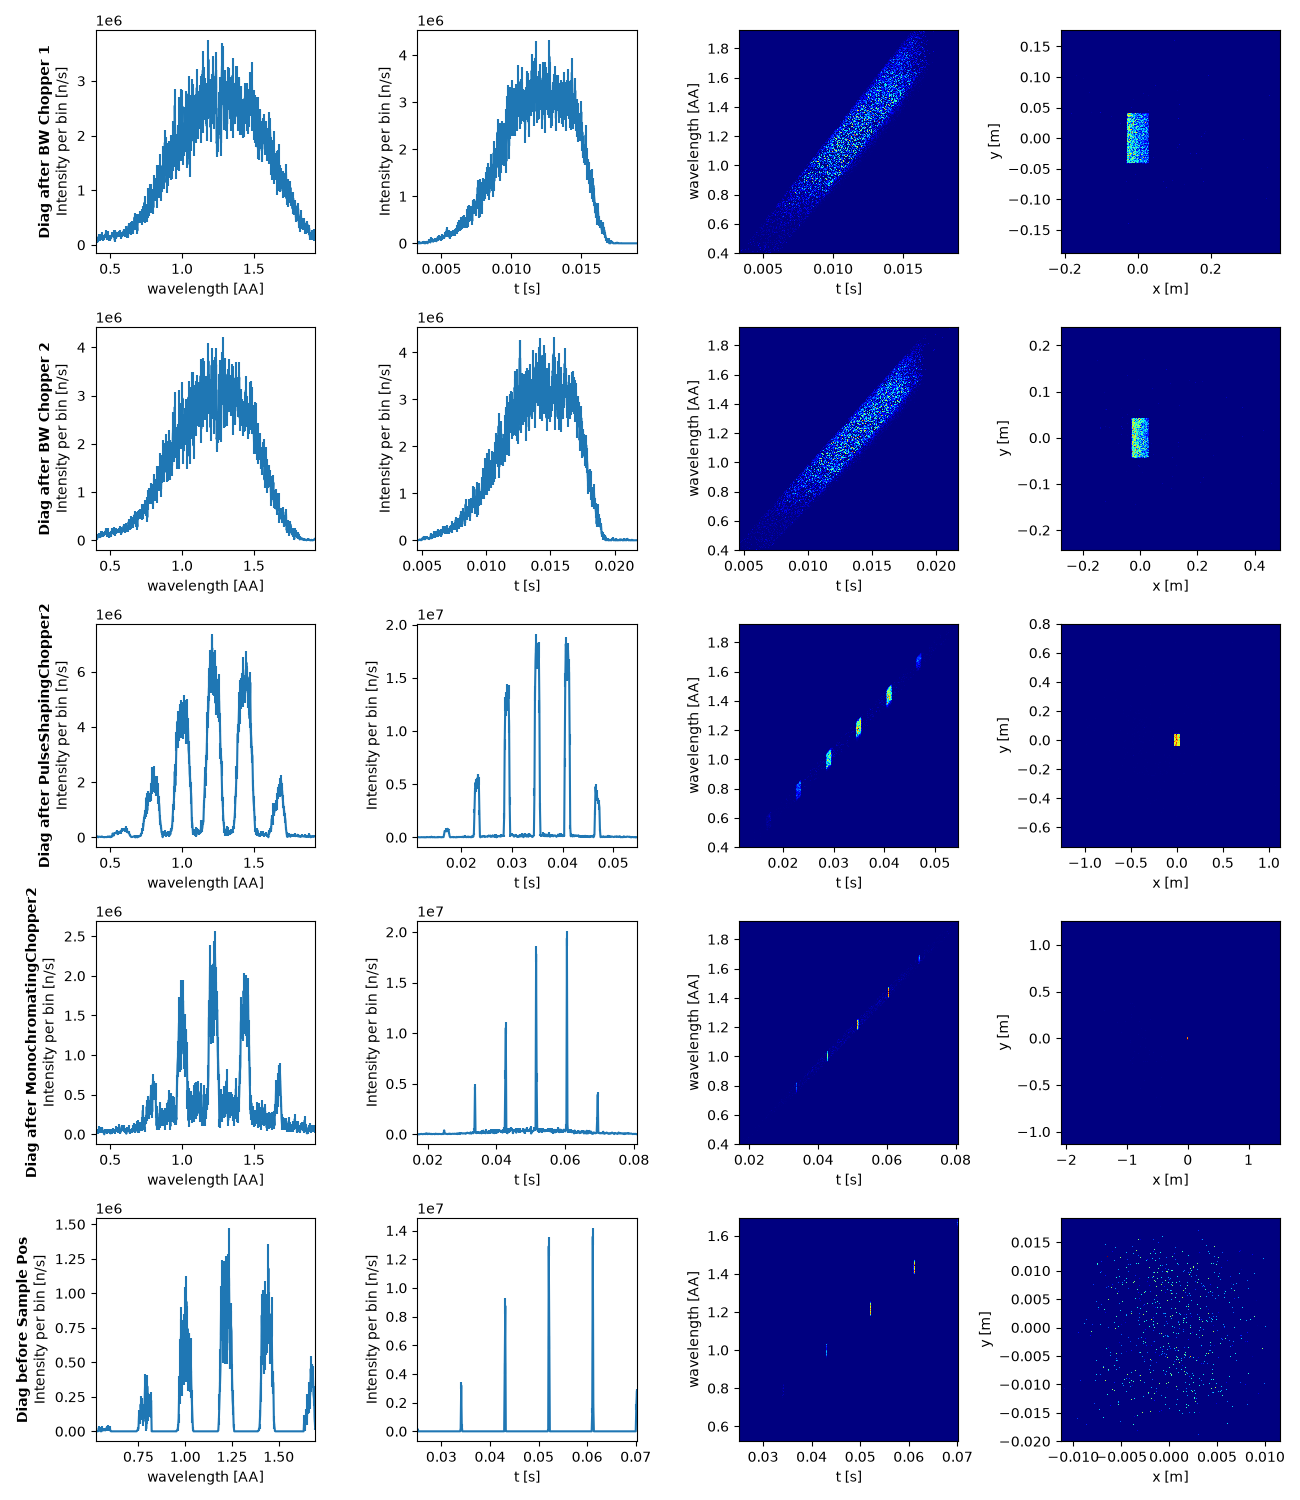

In [51]:
diag.clear_views()
diag.add_view("l", bins=400)
diag.add_view("t", bins=400)
# diag.add_view("t", same_scale=True)
diag.add_view("t", "l", bins=400)
diag.add_view("x", "y", bins=400)

diag.plot()

# Run

In [52]:
# trex.settings(ncount=1e7, suppress_output=True, NeXus=True)  # mpi="auto")
# data = trex.backengine()
# print(data)

In [53]:
# ms.make_sub_plot(data, fontsize=8)

In [54]:
# import mcstasscript.jb_interface as ms_widget

# ms_widget.show(trex)

In [55]:
# trex.show_instrument(backend="pythreejs")

# trex.show_instrument(backend="matplotlib_2d", projection="zx")

In [56]:
# trex.show_instrument(backend="matplotlib_2d", projection="zy")

In [57]:
# trex.show_instrument(backend="matplotlib_2d", projection="xy")

In [58]:
# trex.show_instrument(backend="pythreejs")

In [59]:
# trex.show_diagram(variable="l", limits=[0.8, 3.5])
# trex.show_diagram(analysis=True)